# Chapter 7. 양자 모델 = 푸리에 급수

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 1**

## 학습 목표
- Schuld 등의 정리(2021): 양자 모델은 본질적으로 푸리에 급수임을 실험으로 확인
- 회로 깊이(=인코딩 반복 수)가 접근 가능한 주파수를 결정함을 시각화
- 양자 회로의 출력을 FFT로 분해해 주파수 스펙트럼 분석

이 챕터는 Part 1의 이론적 클라이맥스다.

In [1]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 7.1 정리 (Schuld, Sweke, Meyer 2021)
Angle encoding을 L번 반복하는 양자 회로의 출력은 다음 형태가 된다:

$$f(x; \theta) = \sum_{\omega \in \Omega_L} c_\omega(\theta)\, e^{i\omega x}$$

여기서 $\Omega_L$은 회로 구조가 결정하는 **주파수 집합**이고, $c_\omega(\theta)$는 변분 파라미터의 함수다.

**핵심 메시지:** 회로 깊이 L이 표현 가능한 주파수의 최대값을 결정한다.

## 7.2 단일 인코딩의 주파수 스펙트럼
가장 단순한 회로 `RY(x)`의 출력을 x에 따라 plot하고 FFT로 분해해본다.

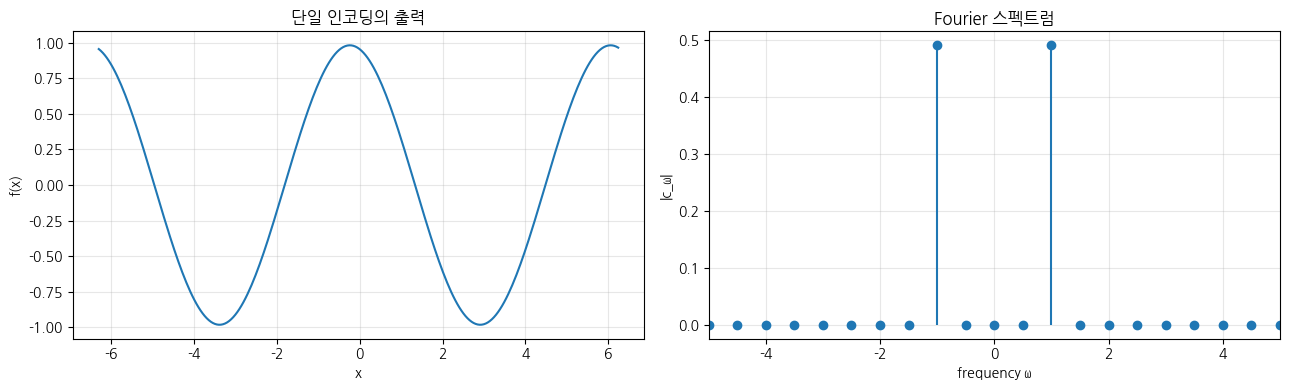

In [2]:
dev = qml.device('default.qubit', wires=1)

@qml.qnode(dev)
def single_layer(x, w1=0.7, w2=0.3):
    qml.RY(x, wires=0)
    qml.RZ(w1, wires=0)
    qml.RY(w2, wires=0)
    return qml.expval(qml.PauliZ(0))

x_vals = np.linspace(-2 * np.pi, 2 * np.pi, 256, endpoint=False)
y_vals = np.array([single_layer(x) for x in x_vals])

# FFT로 주파수 분석
freqs = np.fft.fftshift(np.fft.fftfreq(len(x_vals), d=(x_vals[1] - x_vals[0]))) * 2 * np.pi
spectrum = np.abs(np.fft.fftshift(np.fft.fft(y_vals))) / len(x_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_vals, y_vals)
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_title('단일 인코딩의 출력')
axes[0].grid(alpha=0.3)
axes[1].stem(freqs, spectrum, basefmt=' ')
axes[1].set_xlim(-5, 5)
axes[1].set_xlabel('frequency ω')
axes[1].set_ylabel('|c_ω|')
axes[1].set_title('Fourier 스펙트럼')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

단일 인코딩은 **ω = ±1 두 주파수만** 가진 함수다. 즉, `f(x) = a₀ + a₁cos(x) + b₁sin(x)` 형태.

## 7.3 인코딩 반복 횟수와 주파수 확장
L층 회로에서 접근 가능한 주파수는 -L, -L+1, ..., L-1, L까지다.

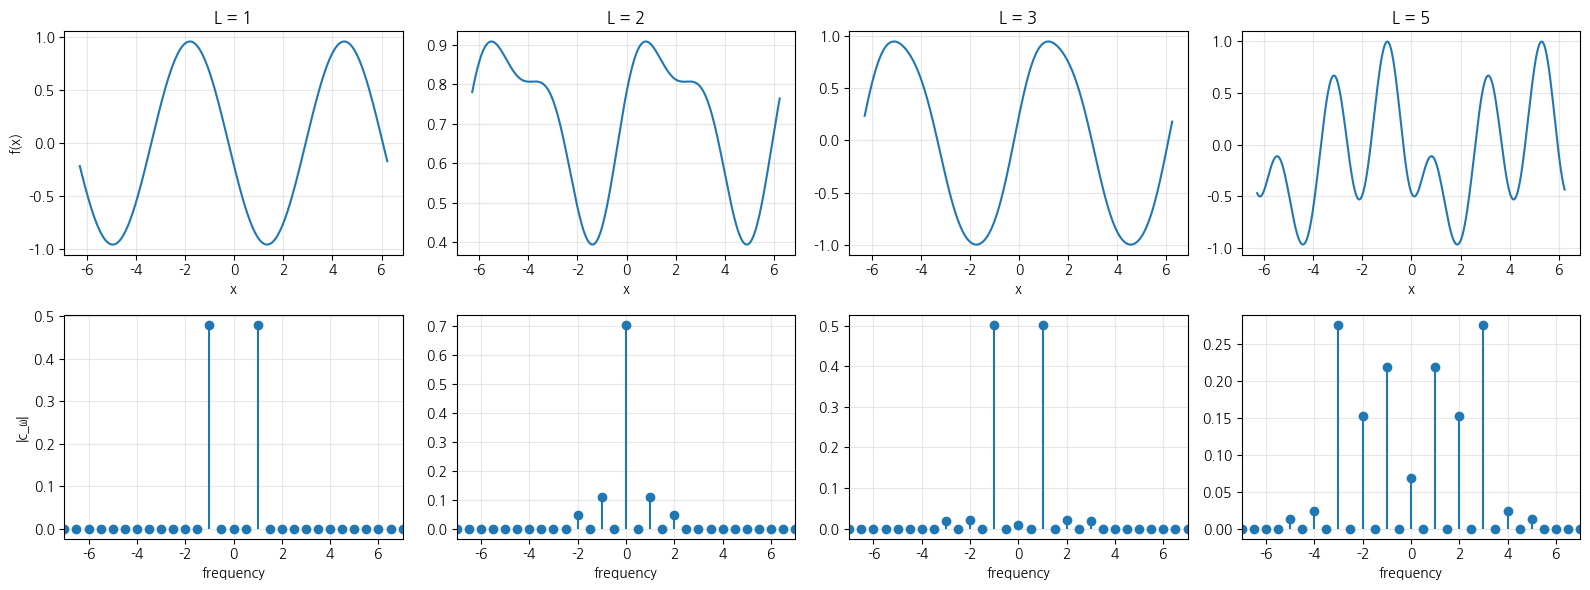

In [3]:
def make_layered_circuit(n_layers):
    dev = qml.device('default.qubit', wires=1)
    @qml.qnode(dev)
    def circ(x, params):
        for layer in range(n_layers):
            qml.RY(x, wires=0)
            qml.RZ(params[2 * layer], wires=0)
            qml.RY(params[2 * layer + 1], wires=0)
        return qml.expval(qml.PauliZ(0))
    return circ

rng = np.random.RandomState(0)
x_vals = np.linspace(-2 * np.pi, 2 * np.pi, 256, endpoint=False)
freqs = np.fft.fftshift(np.fft.fftfreq(len(x_vals), d=(x_vals[1] - x_vals[0]))) * 2 * np.pi

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
layer_counts = [1, 2, 3, 5]

for col, L in enumerate(layer_counts):
    circ = make_layered_circuit(L)
    params = rng.uniform(0, 2 * np.pi, 2 * L)
    y_vals = np.array([circ(x, params) for x in x_vals])
    spectrum = np.abs(np.fft.fftshift(np.fft.fft(y_vals))) / len(x_vals)

    axes[0, col].plot(x_vals, y_vals)
    axes[0, col].set_title(f'L = {L}')
    axes[0, col].grid(alpha=0.3)
    axes[0, col].set_xlabel('x')

    axes[1, col].stem(freqs, spectrum, basefmt=' ')
    axes[1, col].set_xlim(-7, 7)
    axes[1, col].set_xlabel('frequency')
    axes[1, col].grid(alpha=0.3)

axes[0, 0].set_ylabel('f(x)')
axes[1, 0].set_ylabel('|c_ω|')
plt.tight_layout()
plt.show()

**관찰.** L=1이면 ω=±1만 존재한다. L=2면 ω=±2까지, L=3이면 ω=±3까지 ... L층 회로는 정확히 [-L, L] 범위의 정수 주파수를 표현할 수 있다.

## 7.4 함수 근사 능력의 한계
고주파 성분을 가진 함수는 충분히 깊은 회로가 아니면 학습할 수 없다.

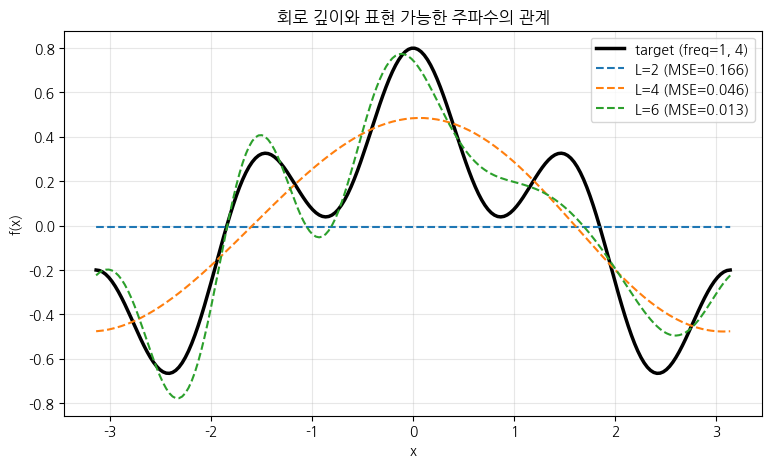

In [4]:
def target_fn(x):
    # 주파수 4의 성분이 포함된 함수
    return 0.5 * np.cos(x) + 0.3 * np.cos(4 * x)

x_train = np.linspace(-np.pi, np.pi, 30)
y_train = target_fn(x_train)

def train_model(n_layers, steps=120):
    circ = make_layered_circuit(n_layers)
    params = pnp.array(
        np.random.RandomState(0).uniform(0, 2 * np.pi, 2 * n_layers),
        requires_grad=True,
    )
    def cost(p):
        preds = pnp.stack([circ(x, p) for x in x_train])
        return pnp.mean((preds - y_train) ** 2)
    opt = qml.AdamOptimizer(0.1)
    for _ in range(steps):
        params = opt.step(cost, params)
    return params, cost(params), circ

results = {L: train_model(L) for L in [2, 4, 6]}

x_plot = np.linspace(-np.pi, np.pi, 200)
plt.figure(figsize=(9, 5))
plt.plot(x_plot, target_fn(x_plot), 'k-', lw=2.5, label='target (freq=1, 4)')
for L, (params, c, circ) in results.items():
    y = np.array([circ(x, params) for x in x_plot])
    plt.plot(x_plot, y, '--', label=f'L={L} (MSE={c:.3f})')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('회로 깊이와 표현 가능한 주파수의 관계')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**해석.** 
- L=2: 주파수 ±2까지만 표현 가능 → 주파수 4 성분을 못 잡아냄
- L=4: 주파수 ±4까지 표현 가능 → 목표 함수에 정확히 도달
- L=6: 여유가 있지만 추가 이득은 없음

이것이 **"양자 모델 설계 = 신호처리 문제"**라는 관점이다.

## 7.5 `qml.fourier`로 회로의 푸리에 계수 직접 추출하기
지금까지는 FFT로 회로 출력에서 푸리에 성분을 "역추정"했다. PennyLane은 회로 자체에서 정확한 푸리에 계수를 추출하는 전용 모듈 `qml.fourier.coefficients`를 제공한다. 이를 사용하면 회로의 표현력을 **해석적으로** 분석할 수 있다.

In [5]:
# 회로의 푸리에 계수 직접 계산
from pennylane import fourier

# 단순 1-층 인코딩 회로
def circuit_1layer(x, params=None):
    # x는 길이 1 배열
    qml.RX(x[0], wires=0)
    qml.RY(0.7, wires=0)
    qml.RZ(0.3, wires=0)
    return qml.expval(qml.PauliZ(0))

dev = qml.device('default.qubit', wires=1)
qnode_1 = qml.QNode(circuit_1layer, dev)

# degree=2까지의 푸리에 계수를 계산
# 첫 인자는 함수, 두 번째는 입력 차원 수, 세 번째는 최대 차수
coeffs_1 = fourier.coefficients(lambda x: qnode_1(x), 1, degree=3)
print(f'L=1 회로의 푸리에 계수:')
for omega, c in enumerate(coeffs_1):
    # 인덱스가 FFT 형식이라 절반 이후는 음의 주파수
    actual_omega = omega if omega <= len(coeffs_1) // 2 else omega - len(coeffs_1)
    print(f'  ω = {actual_omega:+d}: |c_ω| = {abs(c):.4f}')

L=1 회로의 푸리에 계수:
  ω = +0: |c_ω| = 0.0000
  ω = +1: |c_ω| = 0.3824
  ω = +2: |c_ω| = 0.0000
  ω = +3: |c_ω| = 0.0000
  ω = -3: |c_ω| = 0.0000
  ω = -2: |c_ω| = 0.0000
  ω = -1: |c_ω| = 0.3824


**관찰.** ω = ±1만 0이 아닌 값을 가진다 — Part 1 7.2 절의 FFT 분석과 정확히 일치한다.

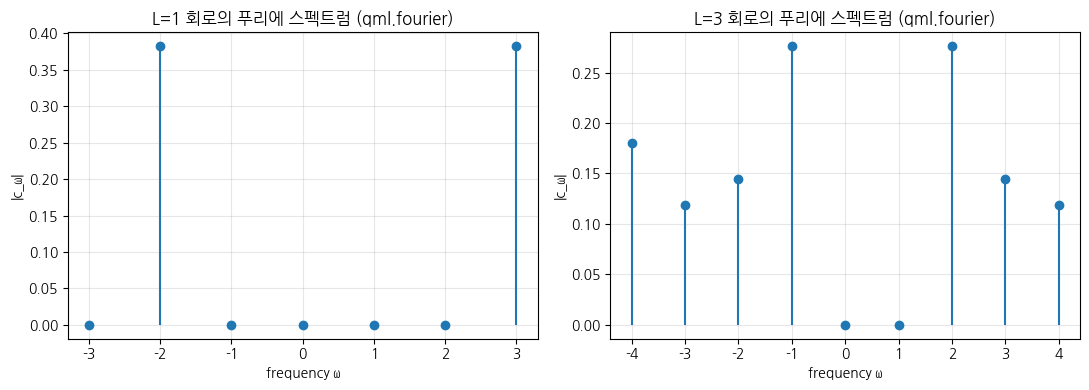

In [6]:
# L=3 회로의 푸리에 계수
def circuit_3layer(x, params):
    for layer in range(3):
        qml.RX(x[0], wires=0)
        qml.RZ(params[2 * layer], wires=0)
        qml.RY(params[2 * layer + 1], wires=0)
    return qml.expval(qml.PauliZ(0))

qnode_3 = qml.QNode(circuit_3layer, dev)
params_fixed = np.array([0.4, 0.7, 1.2, 0.5, 0.9, 0.3])
coeffs_3 = fourier.coefficients(lambda x: qnode_3(x, params_fixed), 1, degree=4)

# L=1과 L=3 비교 plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, coeffs, label in zip(axes, [coeffs_1, coeffs_3], ['L=1', 'L=3']):
    n = len(coeffs)
    freqs = np.fft.fftshift(np.arange(n) - n // 2) if n % 2 == 1 else np.arange(-n // 2, n // 2)
    mags = np.abs(np.fft.fftshift(coeffs))
    ax.stem(freqs, mags, basefmt=' ')
    ax.set_xlabel('frequency ω'); ax.set_ylabel('|c_ω|')
    ax.set_title(f'{label} 회로의 푸리에 스펙트럼 (qml.fourier)')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**결론.** `qml.fourier.coefficients`는 회로의 표현력을 "해석적으로" 진단하는 강력한 도구다. 회로 설계 시 "이 회로가 어떤 주파수까지 표현할 수 있는가"를 학습 없이 미리 확인할 수 있다.

## 7.6 ML 경험자에게 주는 통찰
이 결과는 양자 모델을 신경망의 "신비한 비선형 대안"이 아니라 정량적으로 분석 가능한 모델로 이해하게 해준다.

**요약:**
- 양자 회로 = 매개변수화된 푸리에 급수
- 회로 구조 (특히 인코딩 반복 수) = 표현 가능한 **주파수 집합**
- 변분 파라미터 = **푸리에 계수**
- `qml.fourier`로 계수를 직접 추출해 회로의 표현력을 진단할 수 있음
- 좋은 회로 설계는 "필요한 주파수"를 정확히 포함하는 것